# <span style="color:darkblue"> Lecture 20: Text Analysis </span>

<font size = "5">

Intro text analysis

https://www.youtube.com/watch?v=IRKDrrzh4dE

# <span style="color:darkblue"> I. Setup Working Environment </span>

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

# Import SK-Learn library for machine learning functions
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS 
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split

# Import standard data analysis packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import Kmenas
from sklearn.cluster import MiniBatchKMeans

import faiss

# <span style="color:darkblue"> II. Data </span>

<font size = "5">

We will analyze a dataset on Amazon Reviews

https://www.kaggle.com/datasets/yasserh/amazon-product-reviews-dataset/data


In [2]:
data = pd.read_csv("data_raw/amazon_reviews.csv")

len(data)

1597

<font size = "5">

Check features

In [3]:
data.columns

Index(['id', 'asins', 'brand', 'categories', 'colors', 'dateAdded',
       'dateUpdated', 'dimension', 'ean', 'keys', 'manufacturer',
       'manufacturerNumber', 'name', 'prices', 'reviews.date',
       'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating',
       'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.userCity', 'reviews.userProvince', 'reviews.username', 'sizes',
       'upc', 'weight'],
      dtype='object')

<font size = "5">

Check text

In [4]:
reviews = data["reviews.text"]

<font size = "5">

Check rating

(array([ 42.,   0.,  34.,   0.,   0., 124.,   0., 236.,   0., 741.]),
 array([1. , 1.4, 1.8, 2.2, 2.6, 3. , 3.4, 3.8, 4.2, 4.6, 5. ]),
 <BarContainer object of 10 artists>)

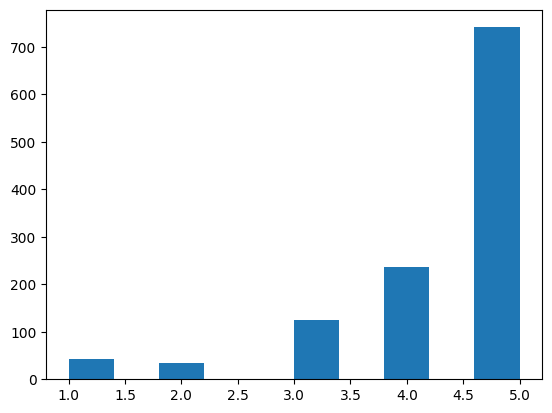

In [5]:
plt.hist(x = data["reviews.rating"])


<font size = "5">

Filter non-missing ratings data

- 26% missing data!
- Could generate selection bias in reviews

In [6]:
# Check for missing values
# A lot of reviews are missing review data
missing_values = data["reviews.rating"].isnull().sum()
percent_missing = missing_values /len(data)
print(percent_missing)

# Extract non-missing data
data_nonmissing = data[data["reviews.rating"].notnull()]

0.2629931120851597


# <span style="color:darkblue"> III. Bag of Words </span>


<font size = "5">

Stop words

- Commonly used words
- Available for different languages



In [7]:
# First ten English stop words
list(ENGLISH_STOP_WORDS)[0:10]

['across',
 'few',
 'hence',
 'nobody',
 'anyone',
 'con',
 'throughout',
 'front',
 'am',
 'they']

<font size = "5">

Create custom stop words

In [8]:
# Here we added Python to the list of stop words
custom_stop_words = list(ENGLISH_STOP_WORDS) + ["Python"]

# You can also create your own list
# custom_stop_words = ["and","or","how"]


<font size = "5">

Count vectorizer

- Check for distinct words across all reviews
- Remove any stop words
- ```min_df``` is used to filter out words depending <br>
on how often they occur. For example, ```min_df=3``` <br>
only keeps words if they are mentioned at least 3 times

In [9]:
word_model = CountVectorizer(min_df=1,
                       stop_words=custom_stop_words)
word_model.fit(reviews)

/Users/zhangxiaobei/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['python'] not in stop_words.
  warnings.warn(


,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,stop_words,"['across', 'few', ...]"
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"
,analyzer,'word'


<font size = "5">

Check Vocabulary

- Check in VS-Code Data Viewer
- You can use preliminary findings to decide whether <br>
to add more stop words

In [16]:
# Extract words in vocabulary and frequency
vocabulary = word_model.vocabulary_
frequency_words  = pd.DataFrame(vocabulary.items(),
                                columns=['Word', 'Frequency']).reset_index


AttributeError: 'function' object has no attribute 'sort_by'

In [ ]:

# Convert to dataframew
frequency_words  = pd.DataFrame(vocabulary.items(),
                                columns=['Word', 'Frequency'])
                                
# Display sorted dataset                                
frequency_words.sort_values(by = "Frequency",ascending=False)

<font size = "5">

Create a dataset counting which words are used <br>
per review

- Each row is a different review
- Each column is a ${0,1}$ indicator on whether that <br>
word was mentioned
- Huge matrix!!

In [21]:
# Create X matrix
X = word_model.transform(reviews)

# Check dimension of X matrix
np.shape(X)

X_dataframe = pd.DataFrame(X)

<font size = "5">

Try it yourself!

Create a bag of words for the column "review.title".

- What are the most common words?



In [23]:
# Write your own code
title_text = data["reviews.title"].fillna("")

title_model = CountVectorizer(min_df=3,
                              stop_words=custom_stop_words)
title_model.fit(title_text)



,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,stop_words,"['across', 'few', ...]"
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"
,analyzer,'word'


# <span style="color:darkblue"> IV. Sentiment Analysis </span>

<font size = "5">
Sentiment analsys uses words to predict user ratings. <br>


- In this case we have ratings labels
- We'll use the data with nonmissing labels


In [25]:
# Write your own code

text = data_nonmissing["reviews.text"]
y    = data_nonmissing["reviews.rating"]

text_train, text_test, y_train, y_test = train_test_split(text, y,
                                                    random_state=0)

<font size = "5">

Extract vectorized X

In [27]:
# Create X matrix
word_model_train = CountVectorizer(min_df=1,
                       stop_words=custom_stop_words)
word_model_train.fit(text_train)
X_train = word_model.transform(text_train)

# Check dimension of X matrix
np.shape(X)

(1597, 6195)

<font size = "5">

We can compress the data using <br>
truncated singular value decomposition (SVD)

- This is an alternative to PCA that is better suited <br>
for sparse, binary data like text

In [29]:
svd = TruncatedSVD(n_components=3,random_state=42);
svd.fit(X_train)
X_svd_train = svd.transform(X_train)
np.shape(X_svd_train)

(882, 3)

[Text(0.5, 0, 'First Principal Component'),
 Text(0, 0.5, 'Second Principal Component')]

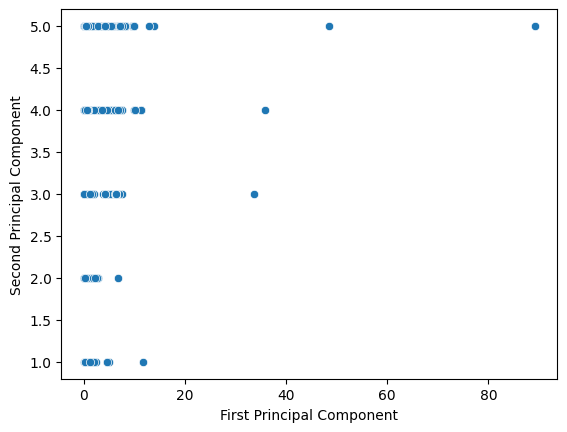

In [31]:
# Hue is used to color
ax = sns.scatterplot(x = X_svd_train[:,0],
                     y = y_train)
ax.set(xlabel='First Principal Component',
       ylabel='Second Principal Component')


<font size = "5">

Try it yourself!

Create a machine learning pipeline

- Run a support vector machine regression to predict user ratings
- What is the out-of-sample performance on the test data?
- Use your data to predict reviews that were missing
- How does the distribution of missing to non-missing reviews compare?



In [ ]:
# Write your own code
pipeline = make_pipeline('pca':``
                         SVC())




<font size = "5">

Try it yourself!

- What happens if you change the minimum frequency of words <br>
and/or change the number of components?

In [19]:
# Write your own code



